# Sentiment Analysis 
Model structure is **DistilBERT encoder + classification head**:
* Backbone: Pretrained sequence classification model loaded from HuggingFace: [distilbert-base-uncased-finetuned-sst-2-english](https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english)
* Task head: binary classifier with num_labels=2 (negative/positive)
* Input construction:
    * tokenize full text without truncation 
    * load the first 255 + last 255 tokens to stay within the 512 token limit
    * add [CLS] and [SEP]
    * pad/truncate to fixed length 512. 
* Note that DistilBERT perfomred better than RNN and longform transformers, which were also tested. Longform could not be properly optimized because of computing contraints.

Handling the imbalance was addressed by weighted loss, and the small-data issue by pretraining and fine-tuning based on f1_negative score to prioritize minority-class performance.

* Transfer learning: started from pretrained, distilled version of the BERT base model, fined tuned on the Stanford Sentiment Treebank dev set.
* Class imbalance mitigation: Class weights of `3:1` (negative:positive) are applied to upweight the minority negative class in custome cross-entropy loss function `WeightedTrainer`. Note that class weights performed better than negative class data augmentation.
* Overfitting control: used early stopping, low learning rates, and a 2-staged fine-tuning strategy.

Key training techniques include a 2 Stage training schedule and hyperparameter tuning. Training/validation split (80/20) is used for all training decisions and hyperparameter evaluation.     

* **Stage 1** — Freeze the DistilBERT backbone; train only the classifier head. (The first stage only underfits data, tops out at 85-86% accuracy.)   
* **Stage 2** — Unfreeze the top 2 transformer layers (layer[4] + layer[5]) and fine-tune everything at a lower LR to avoid overfitting to the training data.

* Hyperparameter search before final training. Randomized trials over LR, weight decay, warmup fraction, and epochs were run, and the best Stage-1 hyperparameters were reused for Stage-2 baseline.  *(Note that the output for the hyperparameter search cell are collapsed by default for viewing convenience.)*
    * Batch size choice: Smaller batches are used with a training and eval batch size if 8.
    * Warmup is used so LR ramps up gradually; weight_decay is also tuned to help control overfitting.

* Optimizer: AdamW, which is Hugging Face Transformers default and worked fine.

**Accuracy of Public Test Set**   
Evaluation results of the final model predictions on the given public test data samples:        

**Model Accuracy:** `90.25%`   

**Confusion matrix:**  
    [168  32]  
    [  7 193] 

See confusion matrix graphic below.

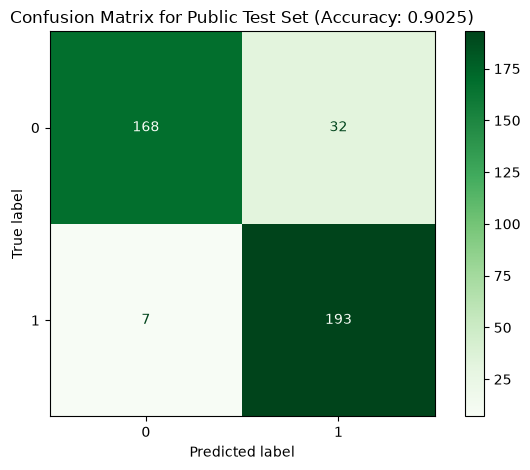

In [47]:
# confusion matrix from saved: public_test_predictions.csv (columns: id, predicted_label)
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

if not os.path.exists("public_test_predictions.csv"):
    print("Skip: run the prediction/export cell first to create public_test_predictions.csv.")
else:
    df_test_raw = pd.read_csv("public_test.csv")
    df_predictions = pd.read_csv("public_test_predictions.csv")

    title = f"Confusion Matrix for Public Test Set (Accuracy: {accuracy_score(df_test_raw['label'], df_predictions['predicted_label']):.4f})"
    y_true = df_test_raw["label"]
    y_pred = df_predictions["predicted_label"]

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Greens")
    disp.ax_.set_title(title)
    plt.tight_layout()
    plt.show()


In [32]:
import re
import pandas as pd
import torch
import numpy as np
import ftfy
from datasets import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score


## Clean Data and Load Tokenizer and Model
* Removes extrenuous characters and collapes white space to prevents model capacity from being wasted on junk tokens. 
* Loads test and training data into data frame.
* Truncates entries to fit 512 token limit for BERT-family transformer by taking first portion (head) and last portion (tail) of each entry 



In [33]:
# TEXT CLEANING

def clean_text(text):
    text = ftfy.fix_text(str(text))               # Fix broken/garbled unicode
    text = re.sub(r"<[^>]+>", " ", text)          # Strip HTML tags
    text = re.sub(r"http\S+|www\S+", " ", text)  # Remove URLs
    text = re.sub(r"\s+", " ", text).strip()      # Collapse whitespace
    return text

# Load raw data first
df_train_raw = pd.read_csv("train.csv")
df_test_raw  = pd.read_csv("public_test.csv")

# Then make cleaned copies for modeling
df_train = df_train_raw.copy()
df_test  = df_test_raw.copy()

df_train["text"] = df_train["text"].apply(clean_text)
df_test["text"]  = df_test["text"].apply(clean_text)
print("Text cleaning done.")
print(f"Train: {len(df_train)} rows | Test: {len(df_test)} rows")

# Convert data frames to HuggingFace Datasets
train_dataset = Dataset.from_pandas(df_train)
test_dataset  = Dataset.from_pandas(df_test)

# TOKENIZE  HEAD and Tail
print("Initializing Tokenizer...")
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def exact_token_head_tail(examples):
    # Tokenize the entire text without truncation or special tokens
    tokenized = tokenizer(examples["text"], add_special_tokens=False, truncation=False)
    
    batch_input_ids = []
    batch_attention_mask = []
    
    for ids in tokenized["input_ids"]:
        # Standard DistilBERT needs 2 slots for [CLS] and [SEP], leaving 510 for text
        if len(ids) > 510:
            # Extract exactly 255 from the front and 255 from the back
            truncated_ids = ids[:255] + ids[-255:]
        else:
            truncated_ids = ids
            
        # Add the special [CLS] (start) and [SEP] (end) tokens manually
        final_ids = [tokenizer.cls_token_id] + truncated_ids + [tokenizer.sep_token_id]
        final_mask = [1] * len(final_ids)
        
        # Pad with 0s if the review is shorter than 512 tokens
        padding_length = 512 - len(final_ids)
        final_ids = final_ids + [tokenizer.pad_token_id] * padding_length
        final_mask = final_mask + [0] * padding_length
        
        batch_input_ids.append(final_ids)
        batch_attention_mask.append(final_mask)
        
    return {"input_ids": batch_input_ids, "attention_mask": batch_attention_mask}

print("Applying Head + Tail tokenization...")
train_dataset = train_dataset.map(exact_token_head_tail, batched=True)
test_dataset = test_dataset.map(exact_token_head_tail, batched=True)

# Format for PyTorch tensors
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print("Tokenization done.")

Text cleaning done.
Train: 240 rows | Test: 400 rows
Initializing Tokenizer...
Applying Head + Tail tokenization...


Map: 100%|██████████| 400/400 [00:00<00:00, 3428.68 examples/s]

Tokenization done.


## Get Input Data Statistics 

Compare raw to clean data. For the DistilBERT tokenizer there are no changes to the text though.  
Count token statistics (high, low average) per entry.  
Print the total nubmer of negative and postive labels with perentage.

In [ ]:
# Original data count tokens per entry from uncleaned text using the same tokenizer (without special tokens)
df = df_train_raw[["text", "label"]].copy()

df["original_token_count"] = df["text"].apply(
    lambda x: len(tokenizer(str(x), add_special_tokens=False, truncation=False)["input_ids"]) 
)

# Overall token statistics
original_max_tokens = int(df["original_token_count"].max())
original_min_tokens = int(df["original_token_count"].min())
original_avg_tokens = float(df["original_token_count"].mean())

print("--- Original Token Statistics (per entry) ---")
print(f"Highest token count: {original_max_tokens}")
print(f"Lowest token count : {original_min_tokens}")
print(f"Average token count: {original_avg_tokens:.2f}")

# Build a clean DataFrame from original training data
df = df_train[["text", "label"]].copy()

# Count tokens per entry using the same tokenizer (without special tokens)
df["token_count"] = df["text"].apply(
    lambda x: len(tokenizer(str(x), add_special_tokens=False, truncation=False)["input_ids"]) 
)

# Overall token statistics
max_tokens = int(df["token_count"].max())
min_tokens = int(df["token_count"].min())
avg_tokens = float(df["token_count"].mean())

# Count labels directly from RAW labels (0/1 only)
raw_labels = pd.to_numeric(df_train["label"], errors="coerce")
total_rows = len(df_train)
neg_count = int((raw_labels == 0).sum())
pos_count = int((raw_labels == 1).sum())
neg_pct = (neg_count / total_rows * 100) if total_rows else 0.0
pos_pct = (pos_count / total_rows * 100) if total_rows else 0.0

print("\n--- Negative/Positive Label Summary ---")
print(f"Total rows     : {total_rows}")
print(f"Negative count : {neg_count} ({neg_pct:.2f}%)")
print(f"Positive count : {pos_count} ({pos_pct:.2f}%)")

--- Original Token Statistics (per entry) ---
Highest token count: 2846
Lowest token count : 25
Average token count: 894.93

--- Negative/Positive Label Summary ---
Total rows     : 240
Negative count : 60 (25.00%)
Positive count : 180 (75.00%)


# 2-Stage Training (Head-only, Partial Unfreeze)
**Stage 1** — Freeze the DistilBERT backbone; train only the classifier head only.     
**Stage 2** — Unfreeze the top 2 transformer layers (layer[4] + layer[5]) and fine-tune everything at a lower LR. Adapts domain representations while perserving pretrained weights.

Training/eval datasets and functions
* Creates a stratified 80/20 train/val split from `train.csv`.     
* Class weights of 3:1 (negative:positive) are applied in the loss function to upweight the minority negative class. 
* Defines `WeightedTrainer` using those weights and `compute_metrics` for accuracy + F1.

In [ ]:
from sklearn.model_selection import train_test_split

#Training/validation split (80/20) is used for all training decisions and hyperparameter evaluation.
train_df_split, val_df_split = train_test_split(
    df_train, test_size=0.2, stratify=df_train["label"], random_state=42
)

train_dataset_main = Dataset.from_pandas(train_df_split.reset_index(drop=True), preserve_index=False)
val_dataset_main   = Dataset.from_pandas(val_df_split.reset_index(drop=True), preserve_index=False)

train_dataset_main = train_dataset_main.map(exact_token_head_tail, batched=True)
val_dataset_main   = val_dataset_main.map(exact_token_head_tail, batched=True)

train_dataset_main.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset_main.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print(f"Train split: {len(train_df_split)} | Val split: {len(val_df_split)}")

# Class weights: 3:1 to upweight negative (minority) class
class_weights = torch.tensor([3.0, 1.0], dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_negative": f1_score(labels, preds, pos_label=0, average="binary"),
        "f1_positive": f1_score(labels, preds, pos_label=1, average="binary"),
    }

print("WeightedTrainer and compute_metrics defined.")


Map: 100%|██████████| 48/48 [00:00<00:00, 2731.30 examples/s]

Train split: 192 | Val split: 48
WeightedTrainer and compute_metrics defined.


In [ ]:
# HELPER: freeze / unfreeze functions

def freeze_backbone(m):
    """Freeze everything except the classification head."""
    for name, param in m.named_parameters():
        param.requires_grad = name.startswith("pre_classifier") or name.startswith("classifier")

def unfreeze_top_layers(m, n_layers=2):
    """Unfreeze the top n transformer layers + classifier head."""
    total_layers = len(m.distilbert.transformer.layer)
    for layer_idx in range(total_layers - n_layers, total_layers):
        for param in m.distilbert.transformer.layer[layer_idx].parameters():
            param.requires_grad = True
    for name, param in m.named_parameters():
        if name.startswith("pre_classifier") or name.startswith("classifier"):
            param.requires_grad = True

def trainable_param_summary(m, label=""):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  {label}: {trainable:,} / {total:,} trainable params ({trainable/total*100:.1f}%)")

print("Freeze/unfreeze helpers defined.")


Freeze/unfreeze helpers defined.


## Hyperparameter Tuning  
Use a fixed stratified validation split and optimize for `f1_negative` first, then accuracy.
This starts with a smoke test, then you can scale `N_TRIALS`.

In [37]:
import random, math, itertools
from transformers import set_seed

search_space = {
    "learning_rate":    [8e-6, 1e-5, 1.2e-5, 1.5e-5],
    "weight_decay":     [0.0, 0.005, 0.01],
    "warmup_fraction":  [0.05, 0.1, 0.15],
    "num_train_epochs": [2, 3, 4],
}

all_configs = [
    {"learning_rate": lr, "weight_decay": wd, "warmup_fraction": wf, "num_train_epochs": ep}
    for lr, wd, wf, ep in itertools.product(*search_space.values())
]

N_TRIALS = 36
random.seed(42)
random.shuffle(all_configs)
trial_configs = all_configs[:N_TRIALS]

results = []
for i, cfg in enumerate(trial_configs, 1):
    set_seed(42 + i)
    steps = math.ceil(len(train_dataset_main) / 8) * cfg["num_train_epochs"]
    warmup = int(cfg["warmup_fraction"] * steps)

    trial_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    if hasattr(trial_model.config, "_attn_implementation"):
        trial_model.config._attn_implementation = "eager"
    freeze_backbone(trial_model)

    trial_trainer = WeightedTrainer(
        model=trial_model,
        args=TrainingArguments(
            output_dir=f"./tuning_runs_stage1/trial_{i}",
            learning_rate=cfg["learning_rate"],
            weight_decay=cfg["weight_decay"],
            warmup_steps=warmup,
            per_device_train_batch_size=8,
            per_device_eval_batch_size=8,
            num_train_epochs=cfg["num_train_epochs"],
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="f1_negative",
            greater_is_better=True,
            logging_steps=999,
            report_to="none",
        ),
        train_dataset=train_dataset_main,
        eval_dataset=val_dataset_main,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
    )
    trial_trainer.train()
    m = trial_trainer.evaluate()
    results.append({**cfg, "f1_neg": m["eval_f1_negative"], "acc": m["eval_accuracy"]})
    print(f"Trial {i:2d}/{N_TRIALS}  f1_neg={m['eval_f1_negative']:.4f}  acc={m['eval_accuracy']:.4f}  lr={cfg['learning_rate']}  wd={cfg['weight_decay']}  ep={cfg['num_train_epochs']}")

results_df = pd.DataFrame(results).sort_values("f1_neg", ascending=False).reset_index(drop=True)
best_config = results_df.iloc[0].to_dict()
results_df.to_csv("tuning_results_distilbert_stage1.csv", index=False)

print("\nBest config:", {k: best_config[k] for k in search_space})
print(f"  f1_neg={best_config['f1_neg']:.4f}  acc={best_config['acc']:.4f}")


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8284.89it/s]
/Users/matt/BERT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Negative,F1 Positive
1,No log,0.426580,0.854167,0.758621,0.895522
2,No log,0.409849,0.854167,0.758621,0.895522


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 15.15it/s]
/Users/matt/BERT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 14.92it/s]
/Users/matt/BERT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Negative,F1 Positive
No log,0.426580,2,0.854167,0.758621,0.895522


Trial  1/36  f1_neg=0.7586  acc=0.8542  lr=1.2e-05  wd=0.0  ep=4


...

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 20245.41it/s]
/Users/matt/BERT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Negative,F1 Positive
1,No log,0.424401,0.854167,0.758621,0.895522
2,No log,0.409187,0.854167,0.758621,0.895522


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 13.62it/s]
/Users/matt/BERT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 14.18it/s]
/Users/matt/BERT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Negative,F1 Positive
No log,0.424401,2,0.854167,0.758621,0.895522


Trial 36/36  f1_neg=0.7586  acc=0.8542  lr=1.5e-05  wd=0.01  ep=3

Best config: {'learning_rate': 1.2e-05, 'weight_decay': 0.0, 'warmup_fraction': 0.1, 'num_train_epochs': 4.0}
  f1_neg=0.7586  acc=0.8542


## Stage 1 Training: Head Classifier 
SFT model weights loaded.  
Used tuned hyperparameters used for training arguments.

In [38]:
import math

model_2stage = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
if hasattr(model_2stage.config, "_attn_implementation"):
    model_2stage.config._attn_implementation = "eager"

freeze_backbone(model_2stage)
trainable_param_summary(model_2stage, "Stage 1")

if "best_config" in globals() and isinstance(best_config, dict):
    cfg_s1 = best_config.copy()
    print("Using in-memory best_config from tuning run.")
else:
    try:
        cfg_s1 = pd.read_csv("tuning_results_distilbert_stage1.csv").iloc[0].to_dict()
        print("Loaded Stage-1 best config from tuning_results_distilbert_stage1.csv")
    except Exception:
        cfg_s1 = {"learning_rate": 1e-5, "weight_decay": 0.01, "warmup_fraction": 0.1, "num_train_epochs": 3}
        print("No tuned config found; using safe defaults.")

lr_s1 = float(cfg_s1.get("learning_rate", 1e-5))
wd_s1 = float(cfg_s1.get("weight_decay", 0.01))
wf_s1 = float(cfg_s1.get("warmup_fraction", 0.1))
ep_s1 = int(cfg_s1.get("num_train_epochs", 3))
warmup_steps_s1 = int(wf_s1 * math.ceil(len(train_dataset_main) / 8) * ep_s1)

print(f"Stage-1 config: lr={lr_s1}  wd={wd_s1}  epochs={ep_s1}  warmup_steps={warmup_steps_s1}")

trainer_s1 = WeightedTrainer(
    model=model_2stage,
    args=TrainingArguments(
        output_dir="./model_2stage/stage1",
        learning_rate=lr_s1,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=ep_s1,
        weight_decay=wd_s1,
        warmup_steps=warmup_steps_s1,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_negative",
        greater_is_better=True,
        logging_steps=10,
        report_to="none",
    ),
    train_dataset=train_dataset_main,
    eval_dataset=val_dataset_main,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)
print("Stage 1 trainer ready.")


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 13660.94it/s]

  Stage 1: 592,130 / 66,955,010 trainable params (0.9%)
Using in-memory best_config from tuning run.
Stage-1 config: lr=1.2e-05  wd=0.0  epochs=4  warmup_steps=9
Stage 1 trainer ready.


In [39]:
print("\n--- Stage 1: Head-only training ---")
trainer_s1.train()
print("Stage 1 training complete.")



--- Stage 1: Head-only training ---


/Users/matt/BERT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Negative,F1 Positive
1,0.700797,0.426580,0.854167,0.758621,0.895522
2,0.442179,0.409849,0.854167,0.758621,0.895522


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 13.66it/s]
/Users/matt/BERT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  9.66it/s]


Stage 1 training complete.


In [40]:
metrics_s1 = trainer_s1.evaluate()
print("\nStage 1 results:")
for k, v in metrics_s1.items():
    if not k.startswith("eval_runtime") and not k.startswith("eval_samples"):
        print(f"  {k}: {round(v, 4)}")


/Users/matt/BERT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Negative,F1 Positive
0.442179,0.426580,2,0.854167,0.758621,0.895522



Stage 1 results:
  eval_loss: 0.4266
  eval_accuracy: 0.8542
  eval_f1_negative: 0.7586
  eval_f1_positive: 0.8955


## Stage 2: Transformer Layer Tuning  
Unfreeze top 2 transformer layers + classification head

In [41]:
# STAGE 2 — Unfreeze top 2 layers + head
# Uses best Stage-1 tuning config as baseline

import math

if "best_config" in globals() and isinstance(best_config, dict):
    cfg_best = best_config.copy()
    print("Using in-memory best_config from tuning run.")
else:
    try:
        cfg_best = pd.read_csv("tuning_results_distilbert_stage1.csv").iloc[0].to_dict()
        print("Loaded best_config from tuning_results_distilbert_stage1.csv")
    except Exception:
        cfg_best = {
            "learning_rate": 1e-5,
            "weight_decay": 0.01,
            "warmup_fraction": 0.1,
            "batch_size": 8,
            "num_train_epochs": 3,
        }
        print("No best_config found; using safe fallback defaults.")

base_lr = float(cfg_best.get("learning_rate", 1e-5))
base_wd = float(cfg_best.get("weight_decay", 0.01))
base_wf = float(cfg_best.get("warmup_fraction", 0.1))
base_bs = int(cfg_best.get("batch_size", 8))
base_ep = int(cfg_best.get("num_train_epochs", 3))

# Stage-2 heuristic from best Stage-1 config: lower LR, similar/bounded schedule
lr_stage2 = max(2e-6, base_lr * 0.5)
wd_stage2 = base_wd
epochs_stage2 = max(2, min(4, base_ep))
warmup_fraction_stage2 = max(0.05, min(0.2, base_wf))

total_batches_s2 = math.ceil(len(train_dataset_main) / base_bs)
total_steps_s2 = total_batches_s2 * epochs_stage2
warmup_steps_s2 = int(warmup_fraction_stage2 * total_steps_s2)

unfreeze_top_layers(model_2stage, n_layers=2)
trainable_param_summary(model_2stage, "Stage 2")

print(f"Stage-2 config: lr={lr_stage2}  wd={wd_stage2}  epochs={epochs_stage2}  warmup_steps={warmup_steps_s2}")

args_stage2 = TrainingArguments(
    output_dir="./model_2stage/stage2",
    learning_rate=lr_stage2,
    per_device_train_batch_size=base_bs,
    per_device_eval_batch_size=base_bs,
    num_train_epochs=epochs_stage2,
    weight_decay=wd_stage2,
    warmup_steps=warmup_steps_s2,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_negative",
    greater_is_better=True,
    logging_steps=10,
    report_to="none",
)

trainer_s2 = WeightedTrainer(
    model=model_2stage,
    args=args_stage2,
    train_dataset=train_dataset_main,
    eval_dataset=val_dataset_main,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

print("Stage 2 trainer ready. Run next cell to start training.")

Using in-memory best_config from tuning run.
  Stage 2: 14,767,874 / 66,955,010 trainable params (22.1%)
Stage-2 config: lr=6e-06  wd=0.0  epochs=4  warmup_steps=9
Stage 2 trainer ready. Run next cell to start training.


In [42]:
print("\n--- Stage 2: Top-2 layers + head fine-tuning ---")
trainer_s2.train()
print("Stage 2 training complete.")



--- Stage 2: Top-2 layers + head fine-tuning ---


/Users/matt/BERT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Negative,F1 Positive
1,0.651490,0.372378,0.895833,0.814815,0.927536
2,0.285636,0.368623,0.875000,0.769231,0.914286


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 13.95it/s]
/Users/matt/BERT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 11.80it/s]


Stage 2 training complete.


In [46]:
metrics_s2 = trainer_s2.evaluate()
print("\nStage 2 results on 20% hold-out validation set:")
for k, v in metrics_s2.items():
    if not k.startswith("eval_runtime") and not k.startswith("eval_samples"):
        print(f"  {k}: {round(v, 4)}")


/Users/matt/BERT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Negative,F1 Positive
0.285636,0.372378,2,0.895833,0.814815,0.927536



Stage 2 results on 20% hold-out validation set:
  eval_loss: 0.3724
  eval_accuracy: 0.8958
  eval_f1_negative: 0.8148
  eval_f1_positive: 0.9275


## Results on Public Testset  
Save Model and Results

In [44]:
# PREDICT, EXPORT SUBMISSION, SAVE RELOADABLE MODEL

from pathlib import Path

active_trainer = trainer_s2 if "trainer_s2" in globals() else trainer_s1
run_tag = "stage2" if "trainer_s2" in globals() else "stage1"

print(f"Predicting on test set using {run_tag} model...")
predictions_active = active_trainer.predict(test_dataset)
pred_labels_active = predictions_active.predictions.argmax(-1)

if predictions_active.label_ids is not None:
    y_true = predictions_active.label_ids
    print(f"Accuracy : {accuracy_score(y_true, pred_labels_active)*100:.2f}%")
    print(f"F1 neg   : {f1_score(y_true, pred_labels_active, pos_label=0, average='binary'):.4f}")
    print(f"F1 pos   : {f1_score(y_true, pred_labels_active, pos_label=1, average='binary'):.4f}")
    print("Confusion matrix:")
    print(confusion_matrix(y_true, pred_labels_active))

# 1) Predicted results from public testset: id, predicted_label
results = df_test[["id"]].copy()
results["predicted_label"] = pred_labels_active
results.to_csv("public_test_predictions.csv", index=False)
print("Saved: public_test_predictions.csv (columns: id, predicted_label)")

# Optional stage-tagged full output for diagnostics
df_test_active = df_test.copy()
df_test_active["predicted_label"] = pred_labels_active
df_test_active.to_csv(f"public_test_predictions_2stage_{run_tag}.csv", index=False)
print(f"Saved: public_test_predictions_2stage_{run_tag}.csv")

# 2) Save model so it can be reloaded from model_checkpoint/
export_dir = Path("model_checkpoint")
export_dir.mkdir(parents=True, exist_ok=True)

active_trainer.model.save_pretrained(export_dir)
tokenizer.save_pretrained(export_dir)

# Save training args for reproducibility
torch.save(active_trainer.args, export_dir / "training_args.bin")

print(f"Saved reloadable model artifacts to: {export_dir.resolve()}")
print("Reload check usage:")
print("  tokenizer = AutoTokenizer.from_pretrained('model_checkpoint')")
print("  model = AutoModelForSequenceClassification.from_pretrained('model_checkpoint')")


Predicting on test set using stage2 model...


/Users/matt/BERT/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Accuracy : 90.25%
F1 neg   : 0.8960
F1 pos   : 0.9082
Confusion matrix:
[[168  32]
 [  7 193]]
Saved: public_test_predictions.csv (columns: id, predicted_label)
Saved: public_test_predictions_2stage_stage2.csv


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 13.91it/s]

Saved reloadable model artifacts to: /Users/matt/BERT/model_checkpoint
Reload check usage:
  tokenizer = AutoTokenizer.from_pretrained('model_checkpoint')
  model = AutoModelForSequenceClassification.from_pretrained('model_checkpoint')


# AI-Use Section and References

Include:   
* Your representative prompts;  
* An explanation of how you verified the correctness of the suggested solutions.  

**Prompt:** What python library can i use for text cleaning?  
**Response:** Use re and ftfy. Provided sample function.   
**Validation:** Tested the code provided and reviewed docus on python.org and ftfy.readthedocs.io. Implemented the code using `fifty.fix_text()` and `re.sub()` to clean text.  

**Prompt:** How do I create a weighted cross entropy loss fuction?  
**Response:** Provided sample code `loss_fn = nn.CrossEntropyLoss(weight=token_weights)` and a helful reference [Emergent Mind: Weighted-cross-entropy-loss](https://www.emergentmind.com/topics/weighted-cross-entropy-loss) 
**Validation:** I reviewed *Emergent Mind* and tested the code to confirm the weights were applied correctly. 

**Prompt:** What's the best pretrained model for sentiment analysis?  
**Response:** Top pretrained models for sentiment analysis included DistilBERT, BERT, RoBERTa, and longformer BidBird based models.  
**Validation:** I revied the model cards on HuggingFace and test the models. The longformer model did not do as well as and took a long time to tune. DistilBERT worked the best and has a SFT version based on the SST-2 devset.   

**Prompt:** How do I setup training a language model to freeze/unfreeze and fine-tune the top transformer layers + head?  
**Response:** Provided sample PyTorch code and logic: Load your pretrained model. Loop through model.parameters() and set requires_grad = False to freeze everything. Access the specific layer indices and classification head, and set their parameters to requires_grad = True. Pass only the trainable parameters to your optimizer.   
**Validation:** Read [PyTorch forums](https://discuss.pytorch.org/t/freezing-model-but-not-sure-its-working/90158) and used the sample code to create helper functions. Developed the classifier head and transformer training routine in using the 2-stage approach. 

*Note: Copilot inline suggestions were also used in VS Code to correct minor syntax errors and improve coding efficiency.*

## References

* [HuggingFace, DistilBERT Transformers](https://huggingface.co/docs/transformers/en/model_doc/distilbert)   
* [Code Academy, Exploring Transformers with HuggingFace](https://www.codecademy.com/learn/intro-to-ai-transformers/modules/exploring-transformers-with-hugging-face/)   
* [PyTorch forums](https://discuss.pytorch.org/t/freezing-model-but-not-sure-its-working/90158)  
* [Emergent Mind: Weighted-cross-entropy-loss](https://www.emergentmind.com/topics/weighted-cross-entropy-loss) 